DATA CLEANING

In [10]:
import pandas as pd

columns_to_keep = [
    'iyear', 'imonth', 'iday', 'country_txt', 'region_txt', 'city',
    'latitude', 'longitude', 'success', 'suicide', 'attacktype1_txt',
    'targtype1_txt', 'gname', 'weaptype1_txt', 'nkill', 'nwound'
]


file_path= '/content/globalterrorismdb_0718dist.csv'

df = pd.read_csv(file_path, encoding='ISO-8859-1', usecols=columns_to_keep, low_memory=False)

# 2. Handling Missing Values

print('----MISSING VALUES----')
missing_data = df.isnull().sum()
print(missing_data)

# Fill casualty counts with 0 (assuming NaN means no recorded casualties)
df['nkill'] = df['nkill'].fillna(0)
df['nwound'] = df['nwound'].fillna(0)

# Drop rows where crucial location data is missing
df.dropna(subset=['latitude', 'longitude', 'city'], inplace=True)


print('----MISSING VALUES AFTER CLEANING----')

print(df.isnull().sum())


----MISSING VALUES----
iyear                  0
imonth                 0
iday                   0
country_txt            0
region_txt             0
city                 435
latitude            4556
longitude           4557
success                0
suicide                0
attacktype1_txt        0
targtype1_txt          0
gname                  0
weaptype1_txt          0
nkill              10313
nwound             16311
dtype: int64
----MISSING VALUES AFTER CLEANING----
iyear              0
imonth             0
iday               0
country_txt        0
region_txt         0
city               0
latitude           0
longitude          0
success            0
suicide            0
attacktype1_txt    0
targtype1_txt      0
gname              0
weaptype1_txt      0
nkill              0
nwound             0
dtype: int64


In [12]:
from sklearn.preprocessing import StandardScaler

# 1. Categorical Transformation (One-Hot Encoding)
# Let's encode 'attacktype1_txt' as an example
attack_dummies = pd.get_dummies(df['attacktype1_txt'], prefix='attack')
df = pd.concat([df, attack_dummies], axis=1)

# 2. Numerical Normalization
# Normalizing casualty counts (nkill and nwound) using StandardScaler
scaler = StandardScaler()
df[['nkill_scaled', 'nwound_scaled']] = scaler.fit_transform(df[['nkill', 'nwound']])

print(df.columns.tolist())

['iyear', 'imonth', 'iday', 'country_txt', 'region_txt', 'city', 'latitude', 'longitude', 'success', 'suicide', 'attacktype1_txt', 'targtype1_txt', 'gname', 'weaptype1_txt', 'nkill', 'nwound', 'attack_Armed Assault', 'attack_Assassination', 'attack_Bombing/Explosion', 'attack_Facility/Infrastructure Attack', 'attack_Hijacking', 'attack_Hostage Taking (Barricade Incident)', 'attack_Hostage Taking (Kidnapping)', 'attack_Unarmed Assault', 'attack_Unknown', 'nkill_scaled', 'nwound_scaled', 'attack_Armed Assault', 'attack_Assassination', 'attack_Bombing/Explosion', 'attack_Facility/Infrastructure Attack', 'attack_Hijacking', 'attack_Hostage Taking (Barricade Incident)', 'attack_Hostage Taking (Kidnapping)', 'attack_Unarmed Assault', 'attack_Unknown']


/tmp/ipykernel_1442/117208641.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='iyear', data=df, palette='viridis')


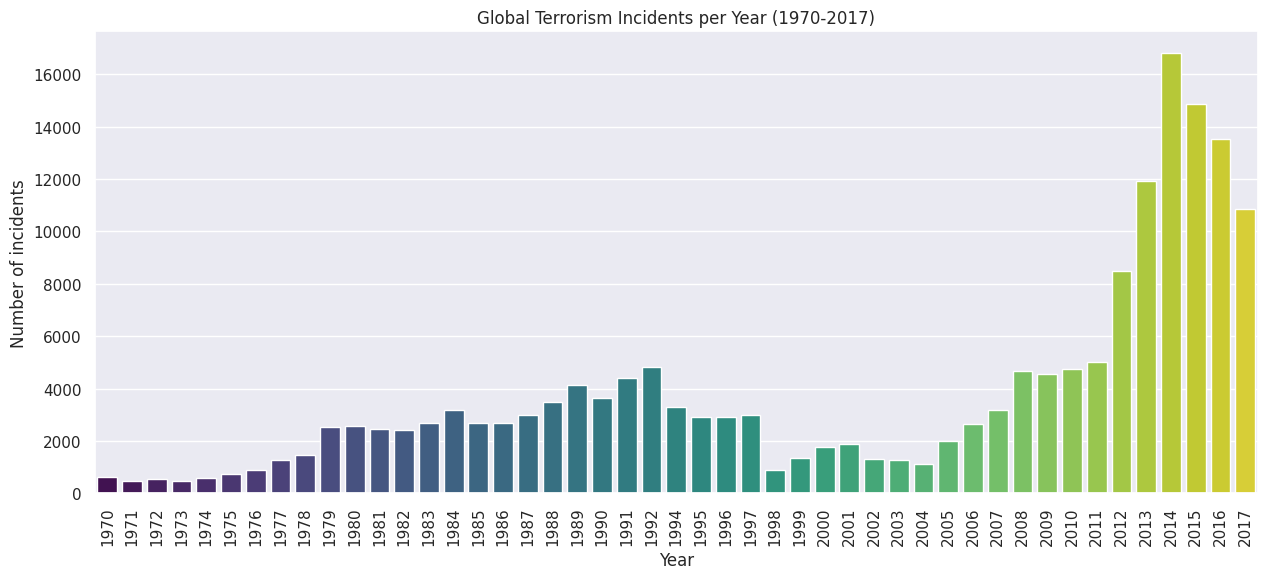

/tmp/ipykernel_1442/117208641.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['region_txt'].value_counts()[:10].index,


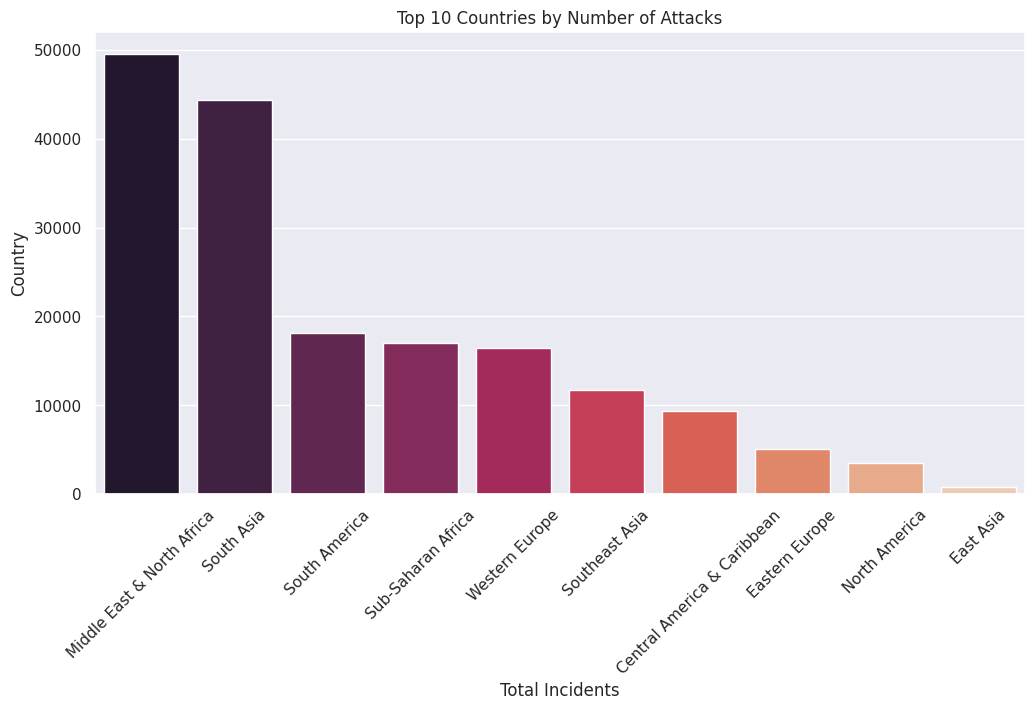

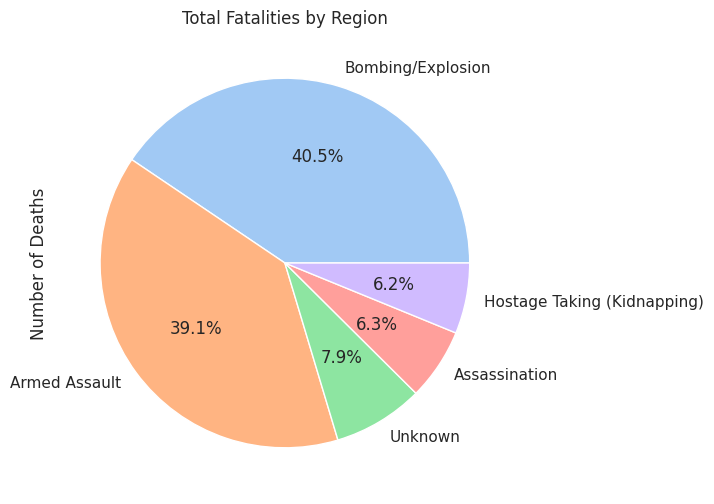

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurer le style
sns.set(style="darkgrid")


plt.figure(figsize=(15, 6))
sns.countplot(x='iyear', data=df, palette='viridis')
plt.xticks(rotation=90)
plt.title('Global Terrorism Incidents per Year (1970-2017)')
plt.xlabel('Year')
plt.ylabel('Number of incidents')
plt.show()

# Visualisation 2 : Top 10 des régions les plus touchées
plt.figure(figsize=(12, 6))
sns.barplot(x=df['region_txt'].value_counts()[:10].index,
            y=df['region_txt'].value_counts()[:10].values,
            palette='rocket')
plt.title('Top 10 Countries by Number of Attacks')
plt.xlabel('Total Incidents')
plt.ylabel('Country')
plt.xticks(rotation=45)
plt.show()

# Visualisation 3 : Type d'attaques vs Nombre de morts (Socio-economic context)
plt.figure(figsize=(12, 6))
top_attacks = df.groupby('attacktype1_txt')['nkill'].sum().sort_values(ascending=False).head(5)
top_attacks.plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Total Fatalities by Region')
plt.ylabel('Number of Deaths')
plt.show()